## RQ3: Can uncertainty or image-level indicators identify unreliable predictions?

In [1]:
import os

import numpy as np
import skimage.io as io

from deepcell.utils.plot_utils import create_rgb_image
from deepcell.utils.plot_utils import make_outline_overlay

npz_dir = r"C:\Users\asus\.deepcell\datasets\tissuenet_v1-1"
train_dict = np.load(os.path.join(npz_dir, 'train.npz'),allow_pickle=True)
val_dict = np.load(os.path.join(npz_dir, 'val.npz'),allow_pickle=True)
test_dict = np.load(os.path.join(npz_dir, 'test.npz'),allow_pickle=True)


In [2]:
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
from IPython.display import clear_output
from torch.nn.functional import relu

from unet import UNet
from tissuenet_data import TissueNetDataset, random_crop
from training_utils import dice_score, train_one_epoch, evaluate, uncertainty_metrics, predictive_entropy

In [3]:
train_X, train_y, train_meta = train_dict['X'], train_dict['y'], train_dict['meta']
val_X, val_y, val_meta = val_dict['X'], val_dict['y'], val_dict['meta']
test_X, test_y, test_meta = test_dict['X'], test_dict['y'], test_dict['meta']

In [4]:
import pandas as pd

train_df = pd.DataFrame(train_meta[1:], columns=train_meta[0])

test_df = pd.DataFrame(test_meta[1:], columns=test_meta[0])
test_df = test_df.loc[3:,:].reset_index(drop=True)

val_df = pd.DataFrame(val_meta[1:], columns=val_meta[0])

In [5]:
held_out_tissue = "Colon"

train_mask = (train_df["specimen"] != held_out_tissue)
train_indices = train_df.index[train_mask].tolist()

val_mask = (val_df["specimen"] != held_out_tissue)
val_indices = val_df.index[val_mask].tolist()

In [6]:
from torch.utils.data import Subset

train_dataset_full = TissueNetDataset(train_X, train_y, training=True)
train_dataset = Subset(train_dataset_full, train_indices)

val_dataset_full = TissueNetDataset(val_X, val_y, training=False)
val_dataset = Subset(val_dataset_full, val_indices)


In [7]:
id_mask = (test_df["specimen"] != held_out_tissue)
id_test_indices = test_df.index[id_mask].to_list()

ood_mask = (test_df["specimen"] == held_out_tissue)
ood_test_indices = test_df.index[ood_mask].to_list()

test_dataset_full = TissueNetDataset(test_X, test_y, training=False)
id_test_dataset = Subset(test_dataset_full, id_test_indices)
ood_test_dataset = Subset(test_dataset_full, ood_test_indices)

In [8]:
batch_size = 2
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
id_test_dataloader = DataLoader(id_test_dataset, batch_size=batch_size, shuffle=False)
ood_test_dataloader = DataLoader(ood_test_dataset, batch_size=batch_size, shuffle=False)

In [9]:
import random
# Use the same seed as baseline A, so the only difference 
# is whether the training set contains "Colon" or not.
seed = 7

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet(n_class=2).to(device)

checkpoint = torch.load(
    "best_no_colon.pt",
    map_location=device,
    weights_only=True,
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("Loaded epoch:", checkpoint["epoch"])
print("Validation Dice:", checkpoint["val_dice"])

per_pixel_loss_fn = nn.BCEWithLogitsLoss(reduction="none")

Loaded epoch: 9
Validation Dice: 0.8874761635823929


In [11]:
id_metrics = uncertainty_metrics(id_test_dataloader, model, per_pixel_loss_fn, device)
ood_metrics = uncertainty_metrics(ood_test_dataloader, model, per_pixel_loss_fn,device)

In [12]:
results_df = pd.DataFrame({"dice": id_metrics["dice"], 
                           "mean_entropy": id_metrics["mean_entropy"], 
                           "p95_entropy": id_metrics["p95_entropy"]})
results_df.head(10)

,dice,mean_entropy,p95_entropy
0,0.795507,0.144270,0.615595
1,0.760646,0.187261,0.666179
2,0.801666,0.173797,0.648266
3,0.755303,0.240762,0.684064
4,0.945596,0.188586,0.671336
5,0.846864,0.061101,0.518033
6,0.918507,0.228502,0.675273
7,0.810802,0.059181,0.497806
8,0.903645,0.108003,0.617542
9,0.936817,0.157970,0.665647


In [25]:
from scipy.stats import spearmanr

for group_name, metrics in [
    ("ID", id_metrics),
    ("OOD", ood_metrics),
]:
    for uncertainty_name in [
        "mean_entropy",
        "p95_entropy",
    ]:
        correlation, p_value = spearmanr(
            metrics[uncertainty_name],
            metrics["dice"],
        )

        print(
            group_name,
            uncertainty_name,
            f": correlation = {correlation:.3f},",
            f"p = {p_value:.3e}",
        )

ID mean_entropy : correlation = -0.290, p = 9.961e-23
ID p95_entropy : correlation = -0.245, p = 1.960e-16
OOD mean_entropy : correlation = -0.202, p = 2.179e-03
OOD p95_entropy : correlation = -0.237, p = 3.043e-04


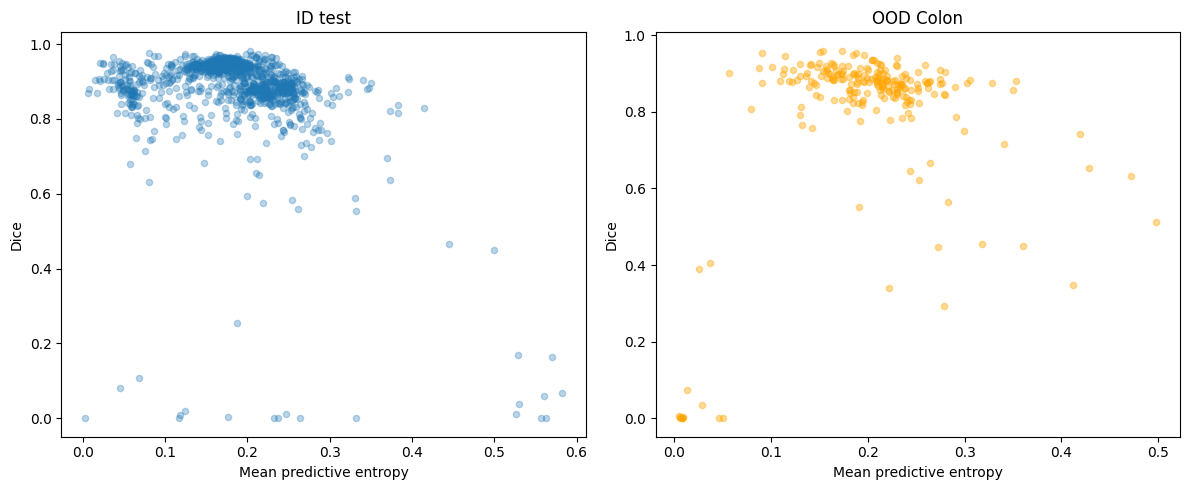

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(
    id_metrics["mean_entropy"],
    id_metrics["dice"],
    alpha=0.3,
    s=20,
)

axes[0].set_title("ID test")
axes[0].set_xlabel("Mean predictive entropy")
axes[0].set_ylabel("Dice")

axes[1].scatter(
    ood_metrics["mean_entropy"],
    ood_metrics["dice"],
    alpha=0.4,
    s=20,
    color="orange",
)

axes[1].set_title("OOD Colon")
axes[1].set_xlabel("Mean predictive entropy")
axes[1].set_ylabel("Dice")

plt.tight_layout()
plt.show()